# DECISION TREE CLASSIFICATION – HEART DISEASE DATASET

## 1. Data Preparation

In [1]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,label_binarize
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, roc_auc_score,
    classification_report,ConfusionMatrixDisplay,
)
import warnings
warnings.filterwarnings('ignore')

In [2]:
file_path = "heart_disease.xlsx"
# Inspecting Data
xls =  pd.ExcelFile(file_path)
xls.sheet_names

['Description', 'Heart_disease']

### Load both sheets separately

In [3]:
df = pd.read_excel(file_path, sheet_name="Heart_disease")     # Main data
df_info = pd.read_excel(file_path, sheet_name="Description")  # Features description

## 2. Exploratory Data Analysis

### Dataset structure & Missing values

In [4]:
df_info

,age,Age in years
0,Gender,"Gender ; Male - 1, Female -0"
1,cp,Chest pain type
2,trestbps,Resting blood pressure
3,chol,cholesterol measure
4,fbs,(fasting blood sugar > 120 mg/dl) (1 = true; 0...
5,restecg,"ecg observation at resting condition, -- Val..."
6,thalch,maximum heart rate achieved
7,exang,exercise induced angina
8,oldpeak,ST depression induced by exercise relative to ...
9,slope,the slope of the peak exercise ST segment


In [5]:
df.shape

(908, 13)

In [6]:
df.info()
df.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    str    
 2   cp        908 non-null    str    
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    object 
 6   restecg   908 non-null    str    
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    str    
 11  thal      908 non-null    str    
 12  num       908 non-null    int64  
dtypes: float64(1), int64(5), object(2), str(5)
memory usage: 132.4+ KB


,count,mean,std,min,25%,50%,75%,max
age,908.0,53.791850,9.158031,29.0,47.75,54.0,60.0,77.0
trestbps,908.0,133.430617,20.401608,0.0,120.00,130.0,144.0,200.0
chol,908.0,201.484581,112.097949,0.0,176.75,224.0,270.0,603.0
thalch,908.0,135.957048,26.804929,60.0,118.00,138.0,156.0,202.0
oldpeak,846.0,0.891253,1.093875,-2.6,0.00,0.5,1.5,6.2
num,908.0,1.008811,1.144436,0.0,0.00,1.0,2.0,4.0


In [7]:
for col in df.select_dtypes(include="object").columns:
    print(col, ":", df[col].unique())

sex : <ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str
cp : <ArrowStringArray>
['typical angina', 'atypical angina', 'asymptomatic', 'non-anginal']
Length: 4, dtype: str
fbs : [True False 'FALSE' 'TRUE']
restecg : <ArrowStringArray>
['lv hypertrophy', 'normal', 'st-t abnormality']
Length: 3, dtype: str
exang : [False True 'FALSE' 'TURE']
slope : <ArrowStringArray>
['downsloping', 'flat', 'upsloping']
Length: 3, dtype: str
thal : <ArrowStringArray>
['fixed defect', 'normal', 'reversable defect']
Length: 3, dtype: str


In [8]:
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

### Visualizations

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'trestbps'}>],
       [<Axes: title={'center': 'chol'}>,
        <Axes: title={'center': 'thalch'}>],
       [<Axes: title={'center': 'oldpeak'}>,
        <Axes: title={'center': 'num'}>]], dtype=object)

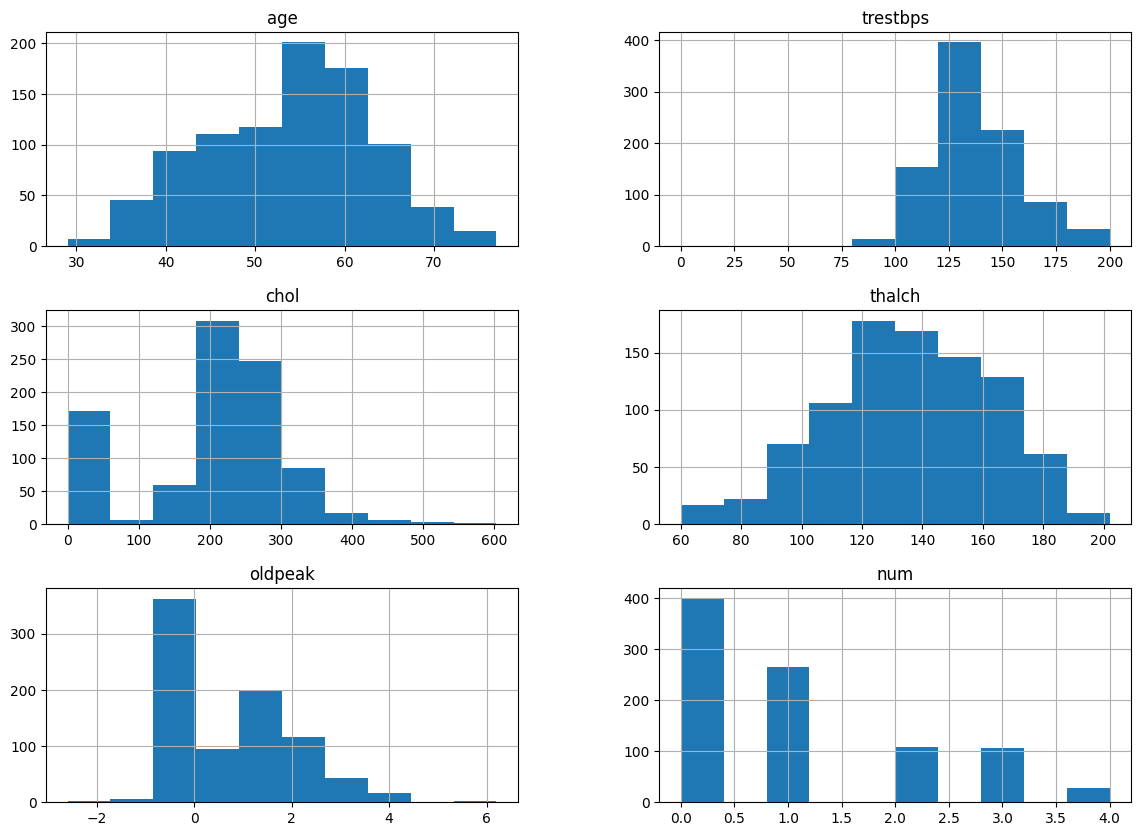

In [9]:
df.hist(figsize=(14,10)) # Histogram for all numerical features

In [10]:
df["num"].value_counts()

num
0    399
1    265
2    109
3    107
4     28
Name: count, dtype: int64

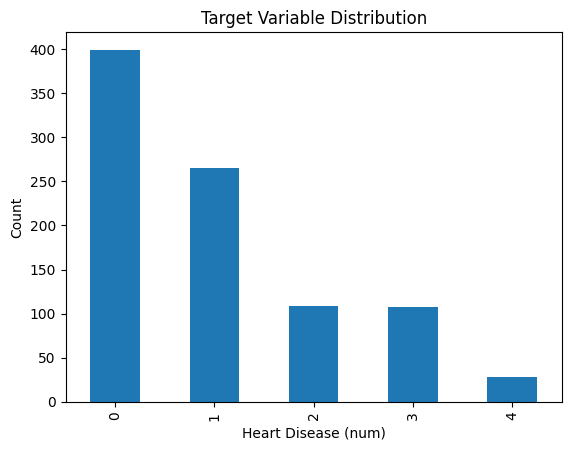

In [11]:
df["num"].value_counts().plot(kind="bar")
plt.title("Target Variable Distribution")
plt.xlabel("Heart Disease (num)")
plt.ylabel("Count")
plt.show()

### Outlier Detection (Box Plots)

<Axes: xlabel='num', ylabel='oldpeak'>

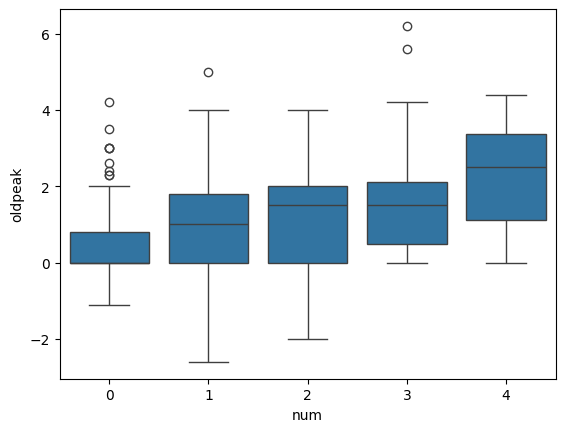

In [12]:
sns.boxplot(data=df, x="num", y="oldpeak")

### Correlation Matrix

<Axes: >

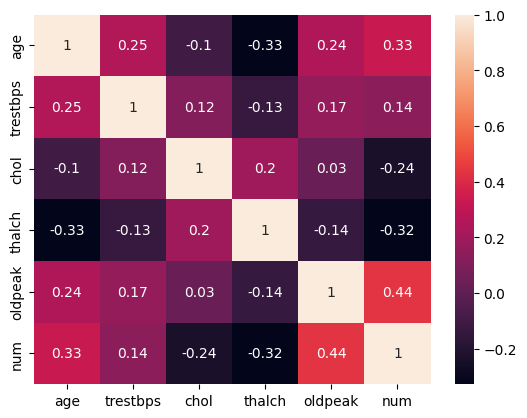

In [13]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

## 3. Feature Engineering

### Data cleaning (based on EDA findings)

### Hard-Clean Missing & Mixed Values

In [14]:
# Convert ALL pandas NA to numpy nan 
df = df.replace({pd.NA: np.nan})

### Fix Boolean Columns (fbs, exang)

In [15]:
df["fbs"] = (
    df["fbs"]
    .replace({"TRUE": True, "FALSE": False})
    .astype(bool)
)

df["exang"] = (
    df["exang"]
    .replace({"TRUE": True, "FALSE": False, "TURE": True})
    .astype(bool)
)

### Fix Invalid Numeric Values
* These zeros are medically impossible

In [16]:
df["chol"] = df["chol"].replace(0, np.nan)
df["trestbps"] = df["trestbps"].replace(0, np.nan)

### Force Numeric Columns to Real Numbers

In [17]:
num_cols = ["age", "trestbps", "chol", "thalch", "oldpeak"]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

### Define Feature Groups

In [18]:
num_cols = ["age", "trestbps", "chol", "thalch", "oldpeak"]
cat_cols = ["sex", "cp", "restecg", "slope", "thal"]
bin_cols = ["fbs", "exang"]

### Build the Preprocessing Pipeline

In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("bin", "passthrough", bin_cols)
    ]
)

## 4. Decision Tree Classification

### Train-Test Split (80-20)

In [20]:
X = df.drop("num", axis=1)
y = df["num"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

### Building Decision Tree Model (with preprocessing)

In [21]:
dt_pipeline = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42))
])

### Train the Decision Tree Model

In [22]:
dt_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers

### Make Predictions

In [23]:
y_pred = dt_pipeline.predict(X_test)

### Model Evaluation

In [24]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.5

Classification Report:

              precision    recall  f1-score   support

           0       0.69      0.74      0.72        80
           1       0.47      0.42      0.44        53
           2       0.11      0.09      0.10        22
           3       0.30      0.38      0.33        21
           4       0.00      0.00      0.00         6

    accuracy                           0.50       182
   macro avg       0.31      0.32      0.32       182
weighted avg       0.49      0.50      0.49       182



### Confusion Matrix

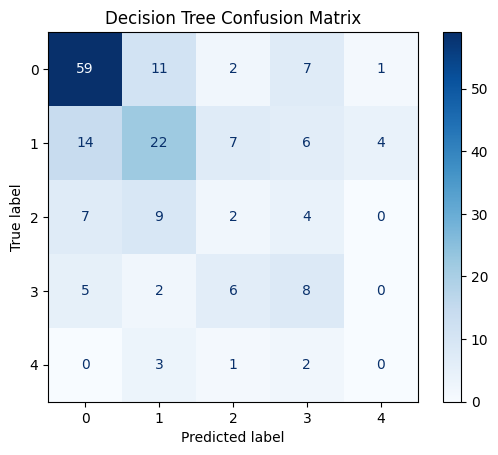

In [25]:
ConfusionMatrixDisplay.from_estimator(
    dt_pipeline,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Decision Tree Confusion Matrix")
plt.show()

### ROC-AUC

In [26]:
y_test_bin = label_binarize(y_test, classes=[0,1,2,3,4])
y_proba = dt_pipeline.predict_proba(X_test)

roc_auc = roc_auc_score(
    y_test_bin,y_proba,
    multi_class="ovr",
    average="weighted"
)

print("ROC-AUC (OVR):", roc_auc)

ROC-AUC (OVR): 0.6524390381669719


The Decision Tree model achieved an ROC-AUC (OVR) score of 0.65, indicating a reasonable discriminative ability across multiple heart disease classes.

## 5. Hyperparameter Tuning

### The Hyperparameter Grid

In [27]:
param_grid = {
    "model__max_depth": [3, 5, 7, 10, None],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__criterion": ["gini", "entropy"]
}

### GridSearchCV Set Up

In [28]:
grid_search = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=param_grid,
    scoring="f1_weighted",   # correct for multiclass
    cv=5,
    n_jobs=-1
)

### Train GridSearchCV

In [29]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__criterion': ['gini', 'entropy'], 'model__max_depth': [3, 5, ...], 'model__min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and paramete

## 6. Model Interpretation & Analysis

### Best Parameters & Best Model

In [30]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV F1-score:")
print(grid_search.best_score_)

Best Parameters:
{'model__criterion': 'gini', 'model__max_depth': 5, 'model__min_samples_split': 10}

Best CV F1-score:
0.5262376820366234


### Re-evaluating The Tuned Model on Test Data

In [31]:
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report (Tuned Model):\n")
print(classification_report(y_test, y_pred_best))

Test Accuracy: 0.5439560439560439

Classification Report (Tuned Model):

              precision    recall  f1-score   support

           0       0.76      0.74      0.75        80
           1       0.43      0.64      0.52        53
           2       0.18      0.09      0.12        22
           3       0.29      0.19      0.23        21
           4       0.00      0.00      0.00         6

    accuracy                           0.54       182
   macro avg       0.33      0.33      0.32       182
weighted avg       0.51      0.54      0.52       182



### Use the Best Tuned Model

In [32]:
best_tree = best_model.named_steps["model"]

In [33]:
feature_names = best_model.named_steps["preprocess"].get_feature_names_out()

### Visualize Decision Tree

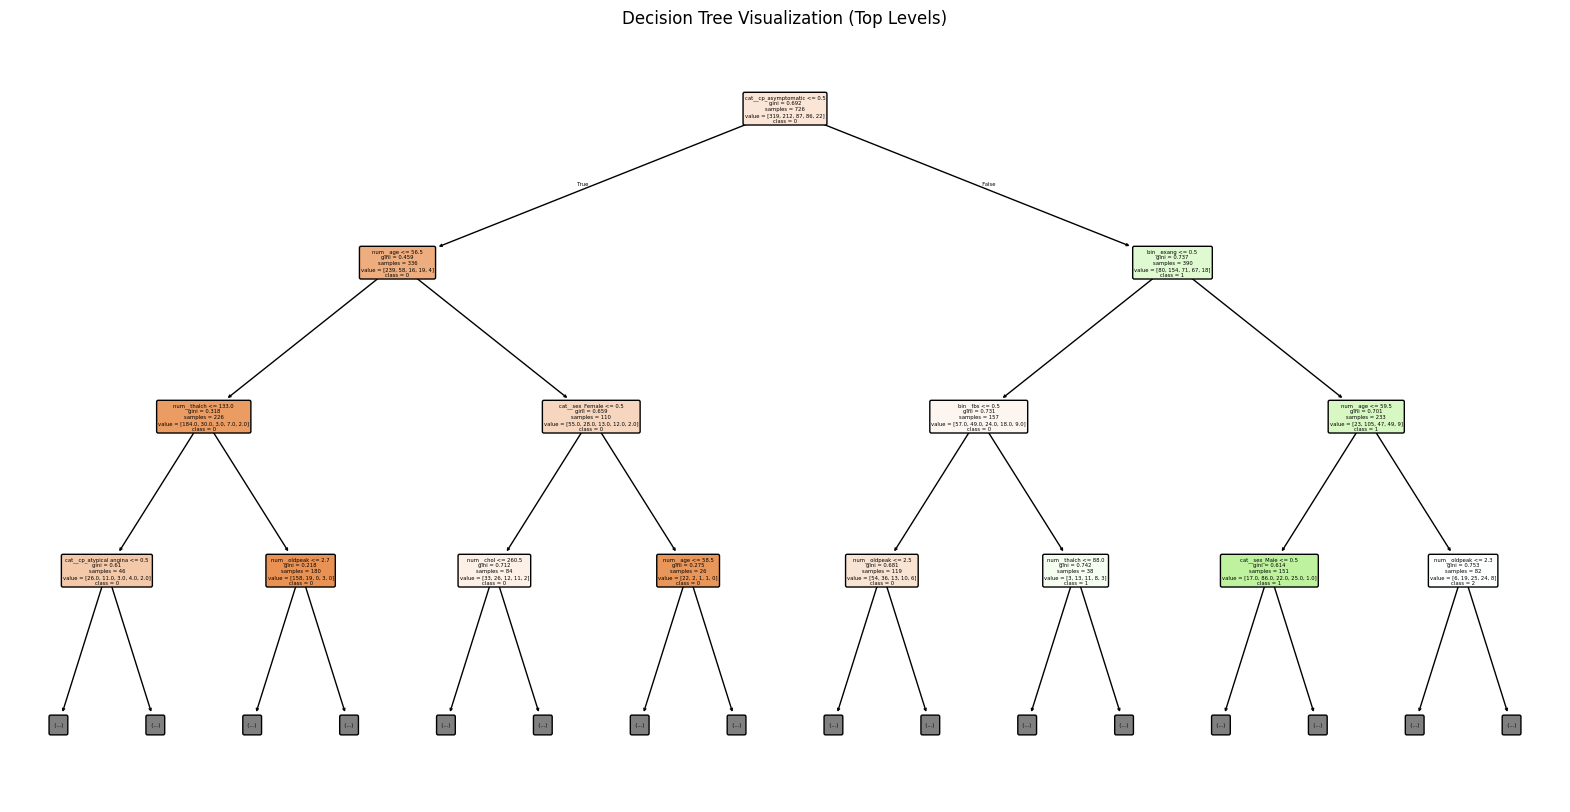

In [34]:
plt.figure(figsize=(20, 10))

tree.plot_tree(
    best_tree,
    feature_names=feature_names,
    class_names=[str(i) for i in sorted(y.unique())],
    filled=True,
    rounded=True,
    max_depth=3   # for clarity
)

plt.title("Decision Tree Visualization (Top Levels)")
plt.show()

### Feature Importance

In [35]:
importances = best_tree.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df.head(10)

,Feature,Importance
7,cat__cp_asymptomatic,0.374418
0,num__age,0.118957
4,num__oldpeak,0.106600
3,num__thalch,0.069912
21,bin__exang,0.058092
2,num__chol,0.046305
1,num__trestbps,0.039945
18,cat__thal_normal,0.038615
5,cat__sex_Female,0.034056
20,bin__fbs,0.033813


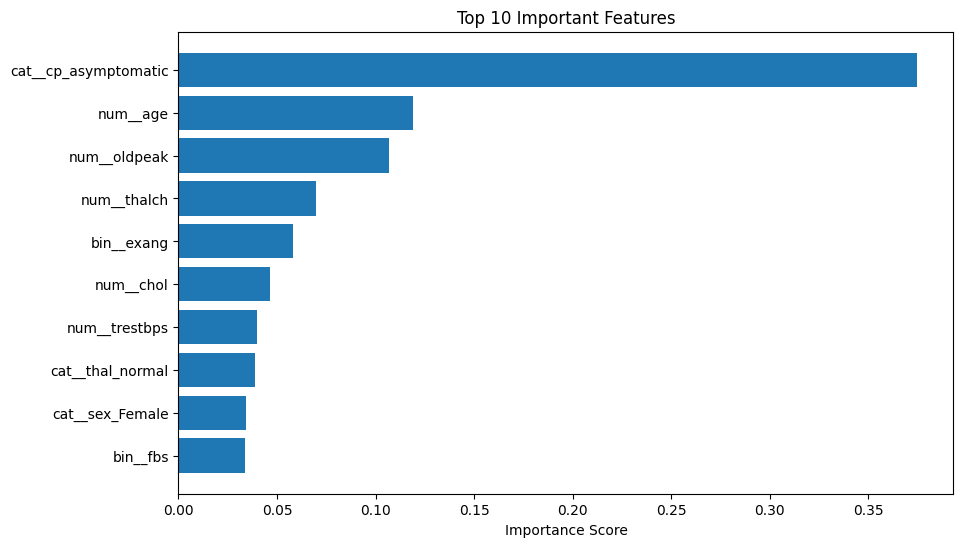

In [36]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance_df["Feature"].head(10),
    feature_importance_df["Importance"].head(10)
)

plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.title("Top 10 Important Features")
plt.show()

## Interview Questions:

**1. Common Decision Tree hyperparameters:**

* max_depth ~ controls overfitting
* min_samples_split ~ prevents noisy splits
* min_samples_leaf ~ improves generalization
* criterion ~ split quality (gini / entropy)

**2. Label Encoding vs One-Hot Encoding:**  
* Label encoding assigns numeric values to categories and may introduce order, 
* whereas one-hot encoding creates binary features and avoids ordinal bias.